1. Loading data and inspecting it

In [1]:
import sys
sys.path.append("../src")

from chess_analytics.data import load_games, validate_games_columns
from chess_analytics.features import build_features

df = load_games("../games.csv")
validate_games_columns(df)

df = build_features(df)
df.head()

,id,rated,created_at,last_move_at,turns,victory_status,winner,increment_code,white_id,white_rating,...,moves,opening_eco,opening_name,opening_ply,rating_diff,num_moves,simple_opening,variation,white_level,black_level
0,TZJHLljE,False,1.504210e+12,1.504210e+12,13,outoftime,white,15+2,bourgris,1500,...,d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...,D10,Slav Defense: Exchange Variation,5,309,13,Slav Defense,Exchange Variation,intermediate,beginner
1,l1NXvwaE,True,1.504130e+12,1.504130e+12,16,resign,black,5+10,a-00,1322,...,d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...,B00,Nimzowitsch Defense: Kennedy Variation,4,61,16,Nimzowitsch Defense,Kennedy Variation,intermediate,intermediate
2,mIICvQHh,True,1.504130e+12,1.504130e+12,61,mate,white,5+10,ischia,1496,...,e4 e5 d3 d6 Be3 c6 Be2 b5 Nd2 a5 a4 c5 axb5 Nc...,C20,King's Pawn Game: Leonardis Variation,3,-4,61,King's Pawn Game,Leonardis Variation,intermediate,intermediate
3,kWKvrqYL,True,1.504110e+12,1.504110e+12,61,mate,white,20+0,daniamurashov,1439,...,d4 d5 Nf3 Bf5 Nc3 Nf6 Bf4 Ng4 e3 Nc6 Be2 Qd7 O...,D02,Queen's Pawn Game: Zukertort Variation,3,-15,61,Queen's Pawn Game,Zukertort Variation,intermediate,intermediate
4,9tXo1AUZ,True,1.504030e+12,1.504030e+12,95,mate,white,30+3,nik221107,1523,...,e4 e5 Nf3 d6 d4 Nc6 d5 Nb4 a3 Na6 Nc3 Be7 b4 N...,C41,Philidor Defense,5,54,95,Philidor Defense,Main line,intermediate,intermediate


2. Feature Engineering

3. Exploratory Data Analysis

In [17]:
from chess_analytics.eda import (
    average_rating_diff_by_opening,
    average_rating_diff_by_victory_status,
    winner_counts,
    victory_status_counts,
)

In [18]:
average_rating_diff_by_opening(df)

simple_opening
Carr Defense                                                  434.0
Australian Defense                                            425.0
King's Gambit Accepted |  Rosentreter-Testa Gambit            390.0
King's Indian |  Orthodox |  7...Nbd7 8.Re1                   327.0
Petrov's Defense #4                                           294.5
                                                              ...  
Benko Gambit Accepted |  Yugoslav |  without 7...Bxf1        -235.0
Blackmar-Diemer Gambit #2                                    -321.0
Valencia Opening                                             -328.0
King's Gambit Accepted |  Dodo Variation                     -502.0
King's Gambit |  Falkbeer Countergambit |  Modern Transfer   -805.0
Name: rating_diff, Length: 227, dtype: float64

In [19]:
average_rating_diff_by_victory_status(df)

victory_status
draw         16.912804
resign        8.870279
mate          5.913992
outoftime     2.883333
Name: rating_diff, dtype: float64

In [20]:
winner_counts(df)

winner
white    10001
black     9107
draw       950
Name: count, dtype: int64

In [21]:
victory_status_counts(df)

victory_status
resign       11147
mate          6325
outoftime     1680
draw           906
Name: count, dtype: int64

4. Prepare Data for ML

In [22]:
from chess_analytics.modeling import train_winner_model

results = train_winner_model(df)

results["accuracy"]

0.6899302093718843

In [23]:
print(results["classification_report"])


              precision    recall  f1-score   support

           0       0.70      0.69      0.69      1816
           1       0.24      0.14      0.18       192
           2       0.71      0.74      0.73      2004

    accuracy                           0.69      4012
   macro avg       0.55      0.52      0.53      4012
weighted avg       0.68      0.69      0.68      4012



(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Feature Importance'}, xlabel='Feature', ylabel='Importance'>)

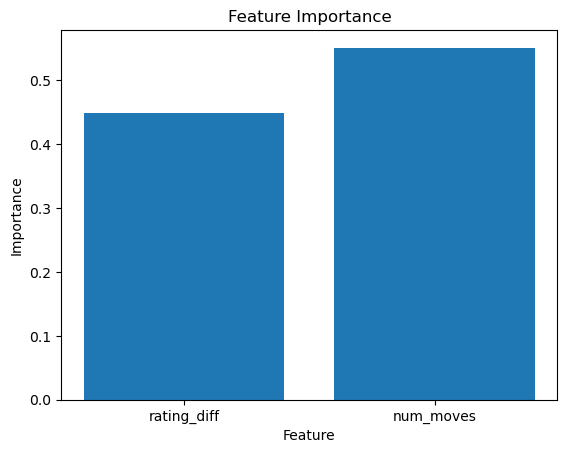

In [24]:
from chess_analytics.plots import plot_feature_importance

plot_feature_importance(results["model"], results["features"].columns)
